# 🚗 AI-Powered Used Car Price Prediction & Market Analytics

### Phase 1: Data Cleaning & Preprocessing

**Objective:**
Prepare the raw Craigslist used car dataset for machine learning by handling missing values, removing invalid records, performing data type conversion, analyzing outliers, and creating new features.

# 📂 1. Data Loading

In this section, we load the dataset into a Pandas DataFrame for further analysis.

In [1]:
# import required libraries
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import warnings

# ignore warning messages
warnings.filterwarnings("ignore")

print("Libraries Imported successfully")

Libraries Imported successfully


In [2]:
# load dataset 
df = pd.read_csv("vehicles.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


# 🔍 2. Data Exploration

Explore the dataset structure, dimensions, data types, summary statistics, and missing values.

In [3]:
# display first 5 rows 

df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [4]:
# number of rows and columns 

print("Rows :", df.shape[0])
print("Columns :",df.shape[1])

Rows : 426880
Columns : 26


In [5]:
# dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [6]:
# check data type 
df.dtypes

id                int64
url                 str
region              str
region_url          str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
image_url           str
description         str
county          float64
state               str
lat             float64
long            float64
posting_date        str
dtype: object

In [7]:
# statistical summary 

df.describe(include='all')

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
count,4.268800e+05,426880,426880,426880,4.268800e+05,425675.000000,409234,421603,252776,249202,...,120519,334022,296677,426812,426810,0.0,426880,420331.000000,420331.000000,426812
unique,NaN,426880,404,413,NaN,NaN,42,29667,6,8,...,4,13,12,241899,360911,NaN,51,NaN,NaN,381536
top,NaN,https://prescott.craigslist.org/cto/d/prescott...,columbus,https://spokane.craigslist.org,NaN,NaN,ford,f-150,good,6 cylinders,...,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,NaN,ca,NaN,NaN,2021-04-23T22:13:05-0400
freq,NaN,1,3608,2988,NaN,NaN,70985,8009,121456,94169,...,63465,87056,79285,7357,231,NaN,50614,NaN,NaN,12
mean,7.311487e+09,NaN,NaN,NaN,7.519903e+04,2011.235191,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.493940,-94.748599,NaN
std,4.473170e+06,NaN,NaN,NaN,1.218228e+07,9.452120,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.841533,18.365462,NaN
min,7.207408e+09,NaN,NaN,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-84.122245,-159.827728,NaN
25%,7.308143e+09,NaN,NaN,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.601900,-111.939847,NaN
50%,7.312621e+09,NaN,NaN,NaN,1.395000e+04,2013.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.150100,-88.432600,NaN
75%,7.315254e+09,NaN,NaN,NaN,2.648575e+04,2017.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.398900,-80.832039,NaN


In [8]:
# check missing values

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

county          426880
size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
long              6549
lat               6549
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
description         70
image_url           68
posting_date        68
dtype: int64

In [9]:
# missing value percentage

missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent      

county          100.000000
size             71.767476
cylinders        41.622470
condition        40.785232
VIN              37.725356
drive            30.586347
paint_color      30.501078
type             21.752717
manufacturer      4.133714
title_status      1.930753
lat               1.534155
long              1.534155
model             1.236179
odometer          1.030735
fuel              0.705819
transmission      0.598763
year              0.282281
description       0.016398
image_url         0.015930
posting_date      0.015930
url               0.000000
price             0.000000
state             0.000000
region_url        0.000000
region            0.000000
id                0.000000
dtype: float64

# 🗑️ 3. Duplicate Handling

Check whether duplicate records exist and remove them to avoid bias during model training.

In [10]:
# check duplicate rows

print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


# 🩺 4. Missing Value Handling

Handle missing values using suitable strategies based on feature importance and percentage of missing data.

In [11]:
# Drop Columns with Extremely High Missing Values

drop_cols = [
    'county',
    'size',
    'VIN',
    'image_url',
    'description'
]

df.drop(columns=drop_cols,
        inplace=True)

print("High Missing Columns Removed")

High Missing Columns Removed


In [12]:
# Fill important categorical features

unknown_cols = [
    'condition',
    'cylinders',
    'drive',
    'paint_color',
    'type'
]
for col in unknown_cols:

    df[col] = df[col].fillna("Unknown")

print("Important Categorical values Filled")

Important Categorical values Filled


In [13]:
# remove missing manufacturer, model and year

df.dropna(

    subset = [
        'manufacturer',
        'model',
        'year'
    ],
    inplace=True
)

print("Essential Missing Rows Removed")

Essential Missing Rows Removed


In [14]:
# Fill small missing values

df['fuel'] = df['fuel'].fillna(df['fuel'].mode()[0])
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])
df['title_status'] = df['title_status'].fillna("clean")

print("Remaning categotrical missing values filled")

Remaning categotrical missing values filled


In [15]:
# fill numerical missing values

df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

print("Numerical Missing values Filled")

Numerical Missing values Filled


In [16]:
# check missing value again

missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [17]:
df.dtypes

id                int64
url                 str
region              str
region_url          str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
drive               str
type                str
paint_color         str
state               str
lat             float64
long            float64
posting_date        str
dtype: object

# 🔄 5. Data Type Conversion

Convert columns into appropriate data types for analysis and machine learning.

In [18]:
# Convert Data Types

# Convert posting date to datetime
df['posting_date'] = pd.to_datetime(
    df['posting_date'],
    utc=True,
    errors='coerce'
)

# Convert year to integer
df['year'] = df['year'].astype(int)

# Convert odometer to integer
df['odometer'] = df['odometer'].astype(int)

print("Data Types Converted Successfully")

Data Types Converted Successfully


In [19]:
df.dtypes

id                            int64
url                             str
region                          str
region_url                      str
price                         int64
year                          int32
manufacturer                    str
model                           str
condition                       str
cylinders                       str
fuel                            str
odometer                      int32
title_status                    str
transmission                    str
drive                           str
type                            str
paint_color                     str
state                           str
lat                         float64
long                        float64
posting_date    datetime64[us, UTC]
dtype: object

In [20]:
print(df.shape)

(404020, 21)


In [21]:
# Statistical summary

df[['price' , 'year', 'odometer']].describe()

,price,year,odometer
count,4.040200e+05,404020.000000,4.040200e+05
mean,6.218580e+04,2011.657180,9.606405e+04
std,1.124254e+07,8.570535,1.888535e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.995000e+03,2009.000000,3.872175e+04
50%,1.399500e+04,2014.000000,8.573900e+04
75%,2.642600e+04,2017.000000,1.324460e+05
max,3.736929e+09,2022.000000,1.000000e+07


# 🚫 6. Invalid Data Removal

Remove unrealistic records using domain knowledge to improve data quality.

In [22]:
# Remove Invalid Price Records

print("Shape Before :", df.shape)
df = df[(df['price'] >= 500) & (df['price'] <= 200000)]
print("Shape After :", df.shape)

print("Invalid Price Records Removed ")

Shape Before : (404020, 21)
Shape After : (364579, 21)
Invalid Price Records Removed 


In [23]:
# Remove Invalid Year

print("Shape Bedore :", df.shape)
df = df[(df['year'] >= 1980) & (df['year'] <= 2022)]
print("Shape After :", df.shape)

print("Invalid year records removed")

Shape Bedore : (364579, 21)
Shape After : (358957, 21)
Invalid year records removed


In [24]:
# Remove invalid Odometer 

print("Shape Before :", df.shape)
df = df[(df['odometer'] >= 1) & (df['odometer'] <= 500000)]
print("Shape After :", df.shape)

print("Invalid Odometer records removed")

Shape Before : (358957, 21)
Shape After : (357751, 21)
Invalid Odometer records removed


In [25]:
# Verify Statistics After Cleaning
df[['price' , 'year', 'odometer']].describe()

,price,year,odometer
count,357751.000000,357751.000000,357751.000000
mean,19270.614531,2012.165987,93375.681480
std,14481.501056,6.241038,63016.026796
min,500.000000,1980.000000,1.000000
25%,7950.000000,2009.000000,39356.000000
50%,15990.000000,2013.000000,87934.000000
75%,27990.000000,2017.000000,135912.000000
max,199999.000000,2022.000000,500000.000000


# 📊 7. Outlier Analysis

Visualize numerical features using boxplots to identify statistical outliers and evaluate whether they should be removed.

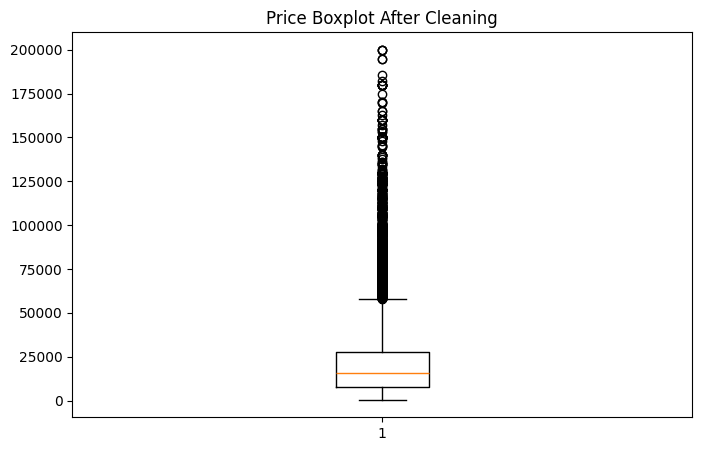

In [26]:
# Price Boxplot After Cleaning

plt.figure(figsize=(8,5))

plt.boxplot(df['price'])

plt.title("Price Boxplot After Cleaning")

plt.show()

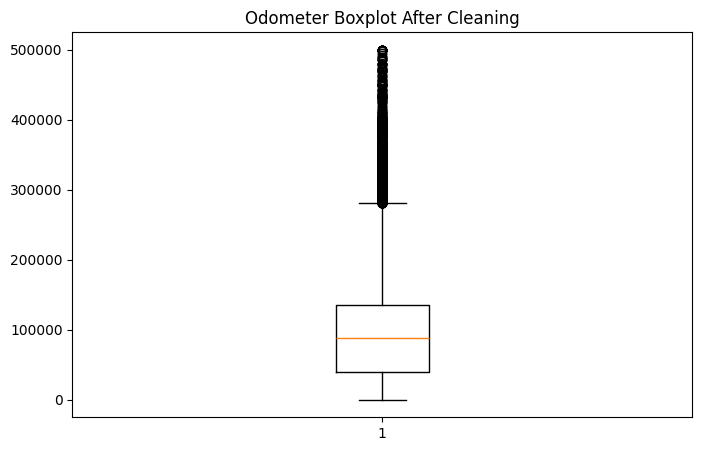

In [27]:
# Odometer Boxplot After Cleaning

plt.figure(figsize=(8,5))

plt.boxplot(df['odometer'])

plt.title("Odometer Boxplot After Cleaning")

plt.show()

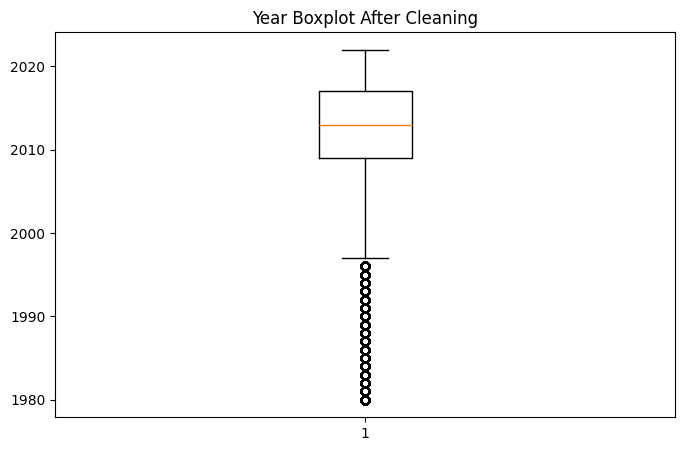

In [28]:
# Year Boxplot After Cleaning

plt.figure(figsize=(8,5))

plt.boxplot(df['year'])

plt.title("Year Boxplot After Cleaning")

plt.show()

In [29]:
# Checkpoint: Dataset Summary

print("Dataset Shape :", df.shape)
print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())

Dataset Shape : (357751, 21)
Missing Values : 0
Duplicate Rows : 0


# ⚙️ 8. Feature Engineering

Create new meaningful features that can improve model performance.

In [30]:
# Create car age

CURRENT_YEAR =2022
df['car_age'] = CURRENT_YEAR - df['year']

print("Car age feature created")

Car age feature created


In [31]:
# Create Mileage per year

df['mileage_per_year'] = (
    df['odometer']/(df['car_age']+1)
)
print("Mileage per year feature created")

Mileage per year feature created


In [32]:
# Create luxuary Brand Feature 

luxury_brands = [
    'bmw',
    'audi',
    'lexus',
    'mercedes-benz',
    'jaguar',
    'tesla',
    'land rover'
]

# Convert Manufacturer name to lowercase
df['is_luxury'] =(
    df['manufacturer']
    .isin(luxury_brands)
    .astype(int)
)

print("Luxary Brand features created")

Luxary Brand features created


## ✅ Phase 1 Summary

Data preprocessing completed successfully.

### Tasks Completed

- ✔ Data Loading
- ✔ Data Exploration
- ✔ Duplicate Handling
- ✔ Missing Value Handling
- ✔ Data Type Conversion
- ✔ Invalid Data Removal
- ✔ Outlier Analysis
- ✔ Initial Feature Engineering

The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

# 📊 Phase 2: Exploratory Data Analysis (EDA)

### Objective

The objective of this phase is to understand the dataset through visualization, identify patterns, discover relationships between variables, and generate business insights that can improve machine learning model performance.

# 1️⃣ Dataset Overview

Understand the overall structure of the cleaned dataset before performing visual analysis.

In [33]:
# Dataset Overview

print("Dataset Shape:",df.shape)
print("\ncolumns")
print(df.columns.tolist())

Dataset Shape: (357751, 24)

columns
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'lat', 'long', 'posting_date', 'car_age', 'mileage_per_year', 'is_luxury']


# 2️⃣ Price Distribution

Analyze how used car prices are distributed.

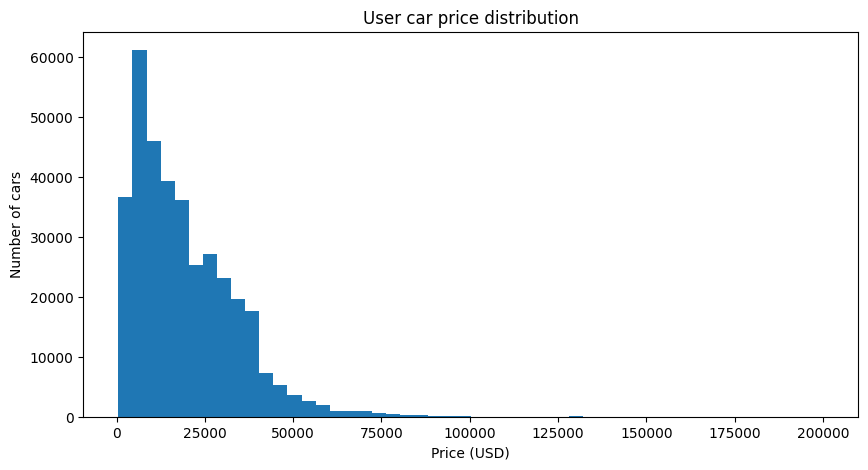

In [34]:
# Price distribution

plt.figure(figsize=(10,5))
plt.hist(df['price'],bins=50)
plt.title("User car price distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Number of cars")
plt.show()

# 3️⃣ Top Manufacturers

Identify the manufacturers with the highest number of listed vehicles.

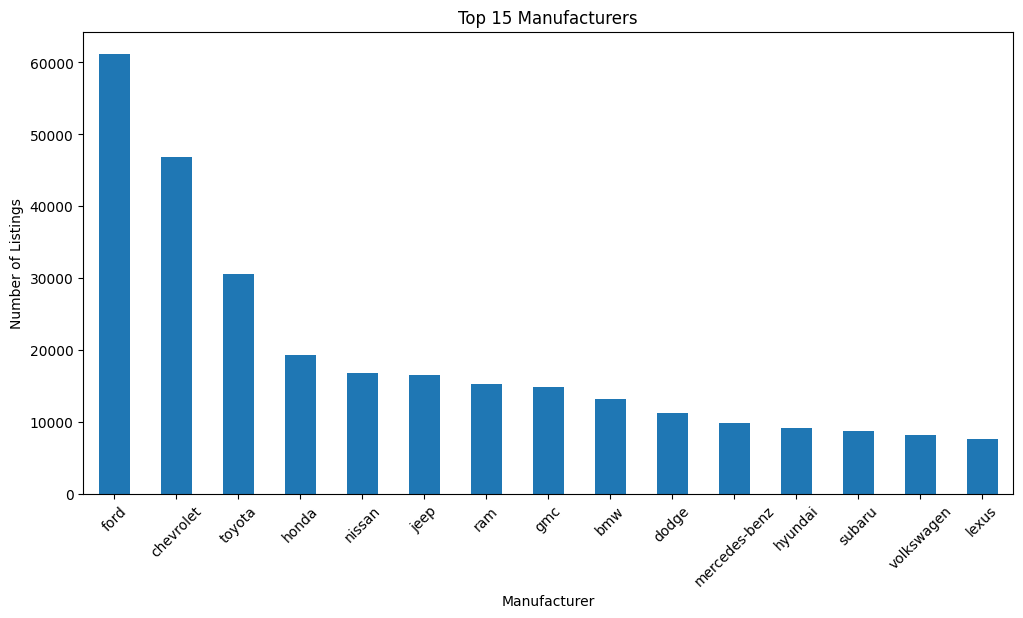

In [35]:
# Top Manufacturers

top_brands = df['manufacturer'].value_counts().head(15)

plt.figure(figsize=(12,6))

top_brands.plot(kind='bar')
plt.title("Top 15 Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

# 4️⃣ Average Price by Manufacturer

Compare the average selling price across manufacturers.

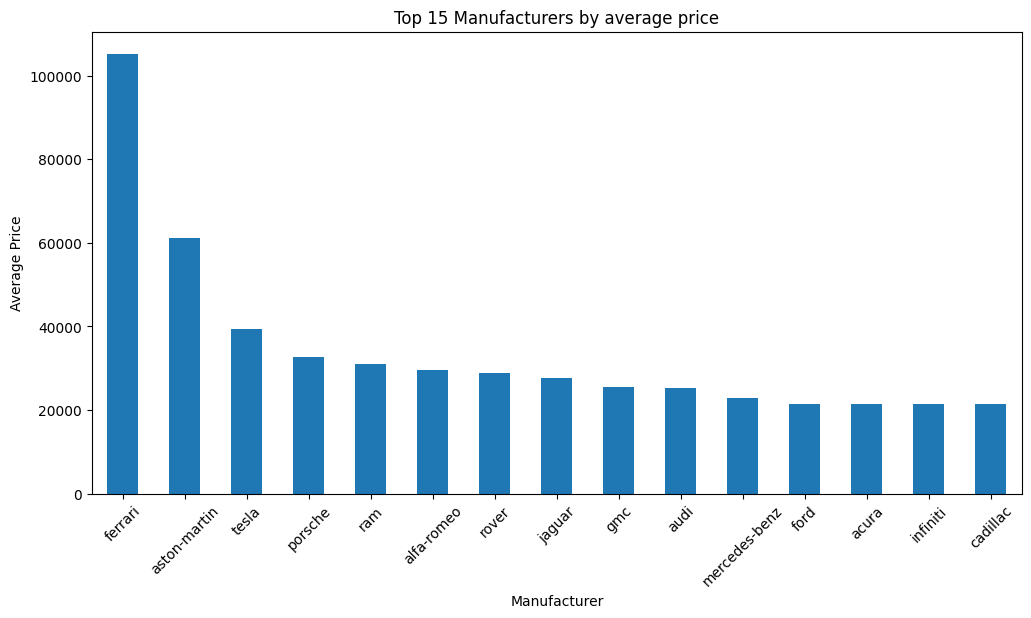

In [36]:
# Average price by Manufacturer

brand_price =(
    df.groupby('manufacturer')['price']
    .mean()
    .sort_values(ascending = False)
    .head(15)
)

plt.figure(figsize=(12,6))
brand_price.plot(kind='bar')

plt.title("Top 15 Manufacturers by average price")
plt.xlabel("Manufacturer")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

# 5️⃣ Fuel Type Analysis

Analyze the distribution of fuel types and compare their average selling prices.

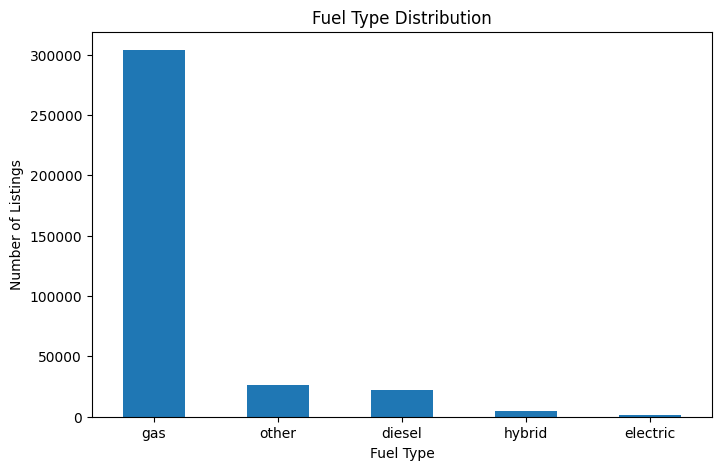

In [37]:
# Fuel Type Distribution

fuel_count = df['fuel'].value_counts()
plt.figure(figsize=(8,5))
fuel_count.plot(kind='bar')

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)

plt.show()

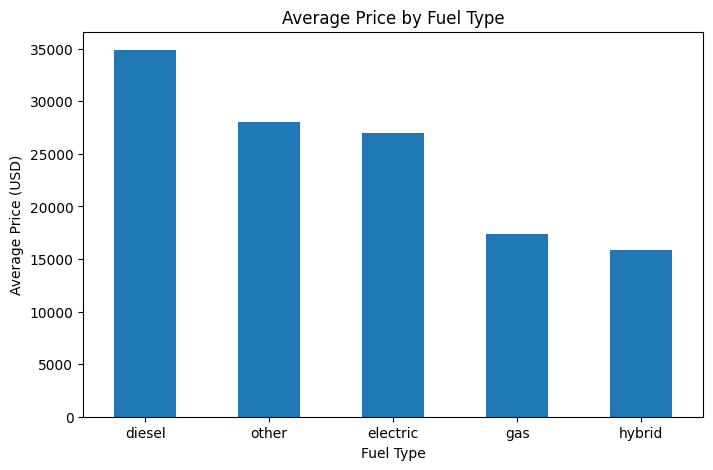

In [38]:
# Average Price by Fuel Type

fuel_price = (
    df.groupby('fuel')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
fuel_price.plot(kind='bar')

plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)

plt.show()

# 6️⃣ Transmission Analysis

Compare the distribution and average prices of different transmission types.

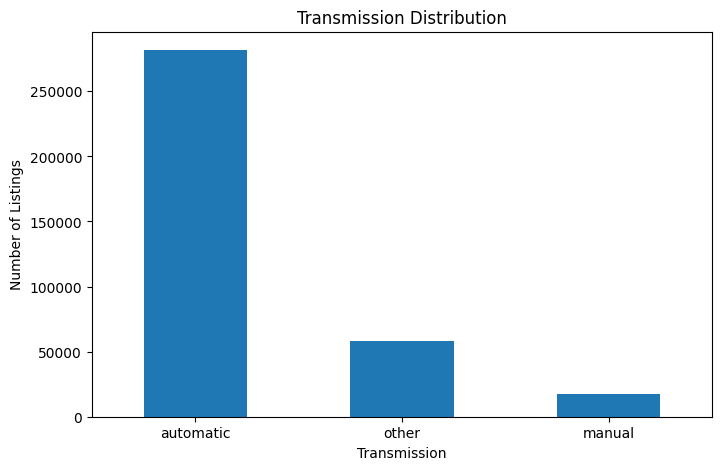

In [39]:
# Transmission Distribution

transmission_count = df['transmission'].value_counts()

plt.figure(figsize=(8,5))
transmission_count.plot(kind='bar')

plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)

plt.show()

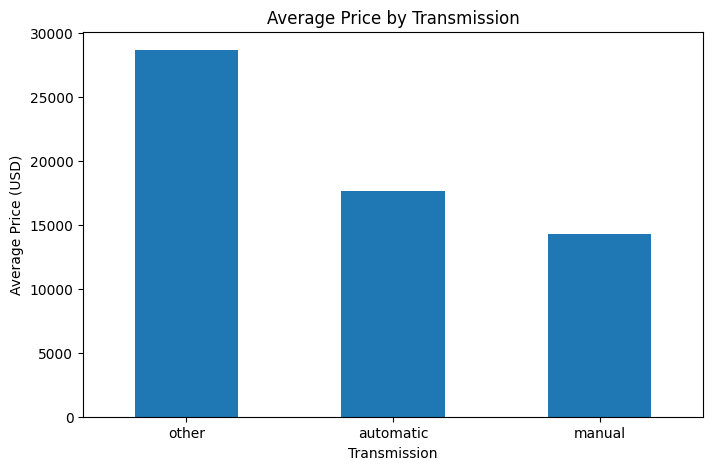

In [40]:
# Average Price by Transmission

transmission_price = (
    df.groupby('transmission')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
transmission_price.plot(kind='bar')

plt.title("Average Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)

plt.show()

# 7️⃣ Vehicle Type Analysis

Analyze the distribution of different vehicle body types.

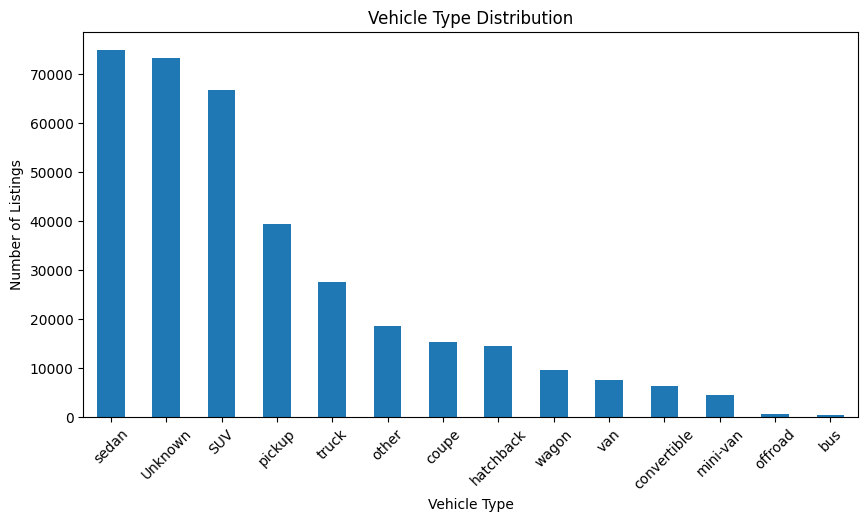

In [41]:
# Vehicle Type Distribution

vehicle_count = df['type'].value_counts()

plt.figure(figsize=(10,5))
vehicle_count.plot(kind='bar')

plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

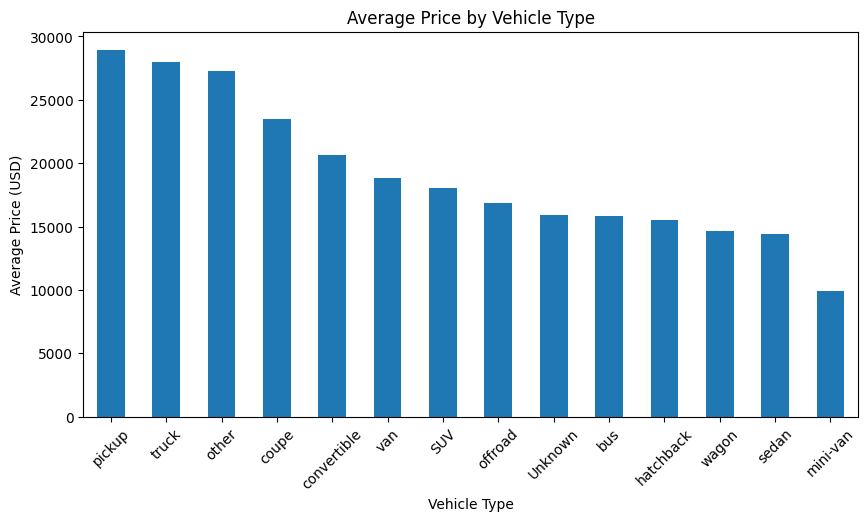

In [42]:
# Average Price by Vehicle Type

vehicle_price = (
    df.groupby('type')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
vehicle_price.plot(kind='bar')

plt.title("Average Price by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)

plt.show()

# 8️⃣ Vehicle Condition Analysis

Analyze vehicle conditions and compare their average resale prices.

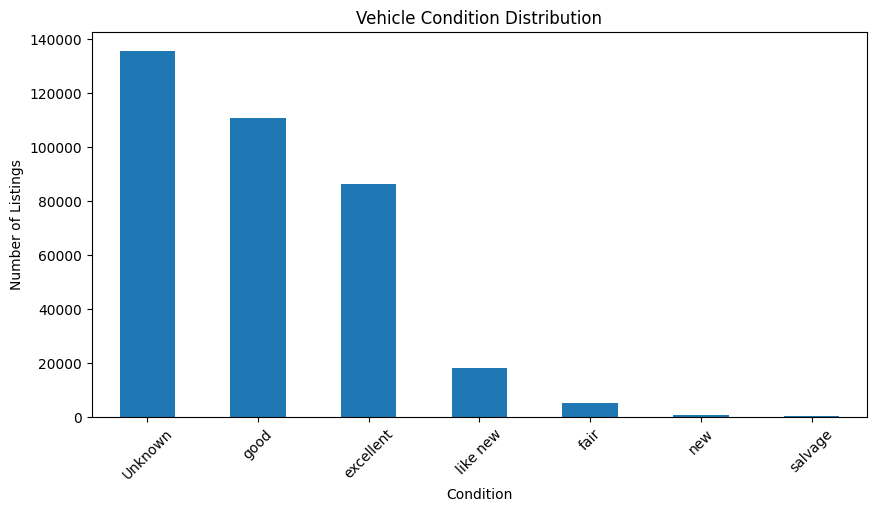

In [43]:
# Vehicle Condition Distribution

condition_count = df['condition'].value_counts()

plt.figure(figsize=(10,5))
condition_count.plot(kind='bar')

plt.title("Vehicle Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

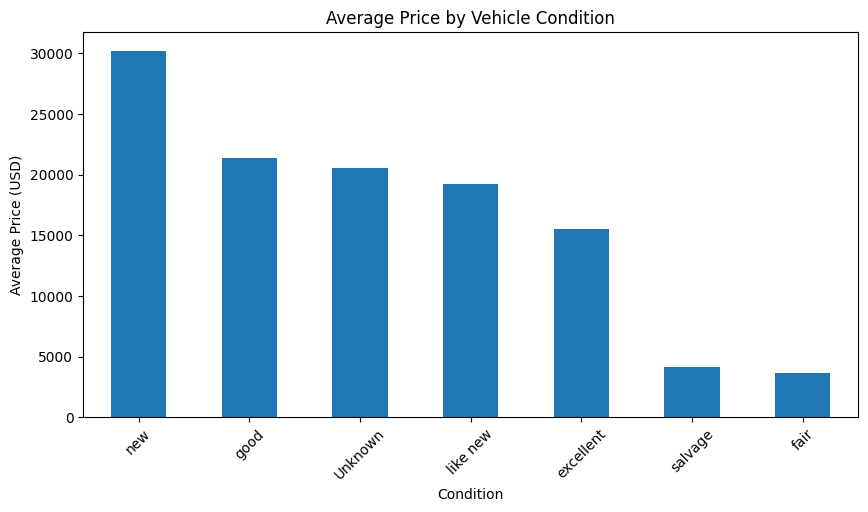

In [44]:
# Average Price by Condition

condition_price = (
    df.groupby('condition')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
condition_price.plot(kind='bar')

plt.title("Average Price by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)

plt.show()

# 9️⃣ State-wise Analysis

Analyze the geographical distribution of used car listings and compare average prices across different states.

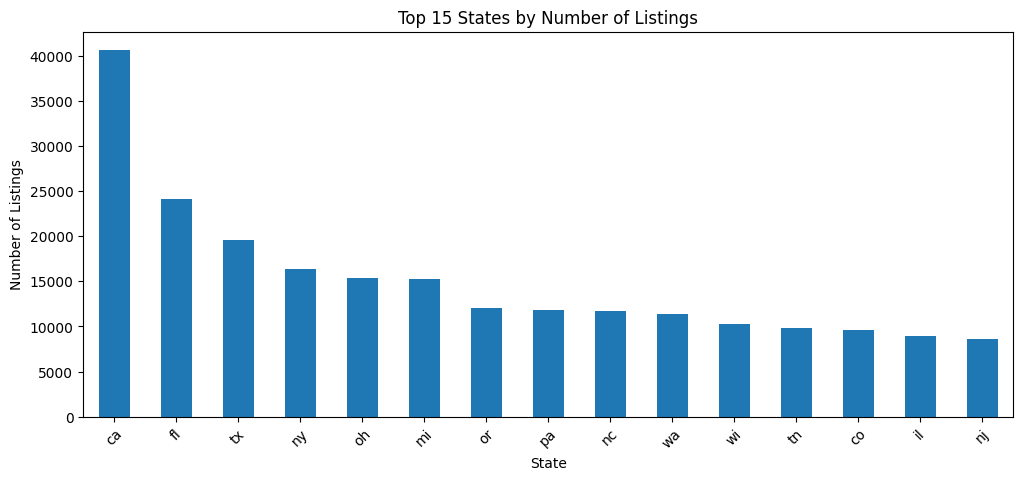

In [45]:
# Top States by Listings

state_count = df['state'].value_counts().head(15)

plt.figure(figsize=(12,5))
state_count.plot(kind='bar')

plt.title("Top 15 States by Number of Listings")
plt.xlabel("State")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

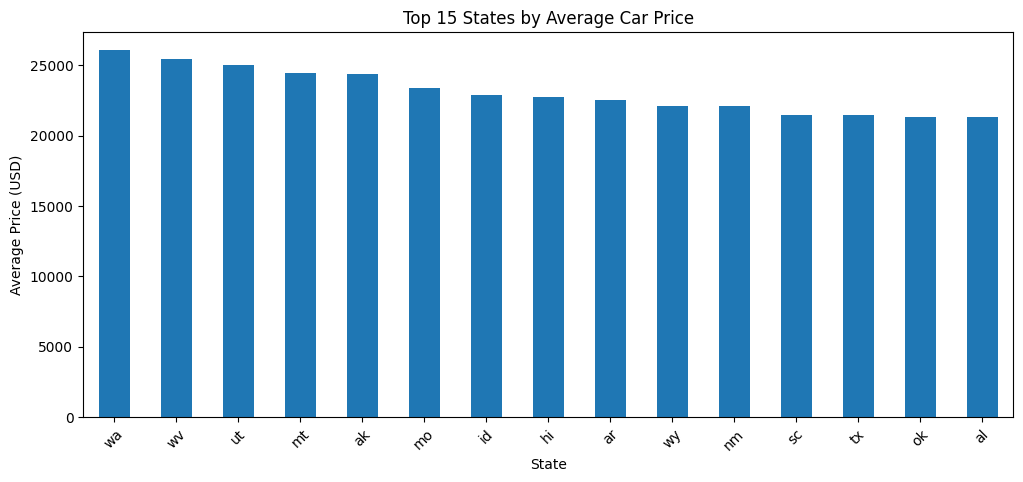

In [46]:
# Average Price by State

state_price = (
    df.groupby('state')['price']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,5))
state_price.plot(kind='bar')

plt.title("Top 15 States by Average Car Price")
plt.xlabel("State")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)

plt.show()

# 🔟 Manufacturing Year vs Price

Analyze how vehicle age affects resale price.

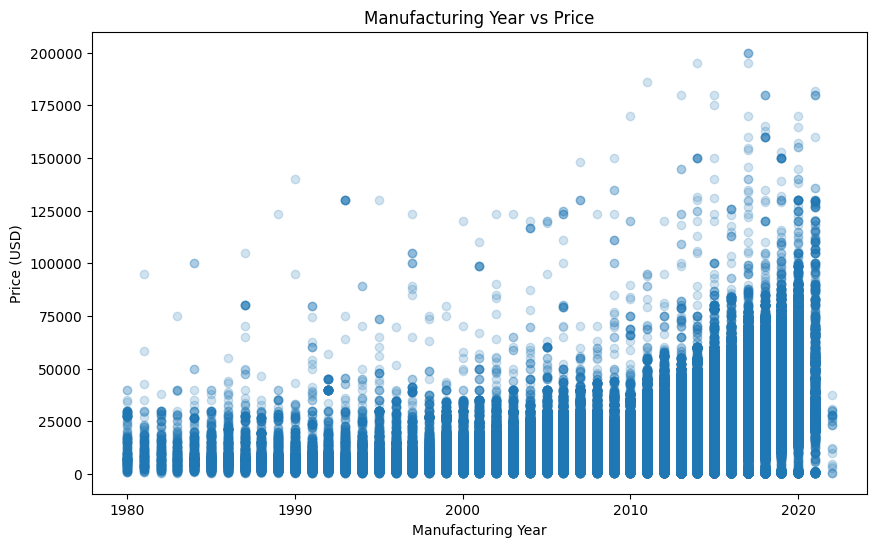

In [47]:
# Year vs Price

plt.figure(figsize=(10,6))

plt.scatter(
    df['year'],
    df['price'],
    alpha=0.2
)

plt.title("Manufacturing Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price (USD)")

plt.show()

# 1️⃣1️⃣ Odometer vs Price

Analyze the relationship between vehicle mileage and resale price.

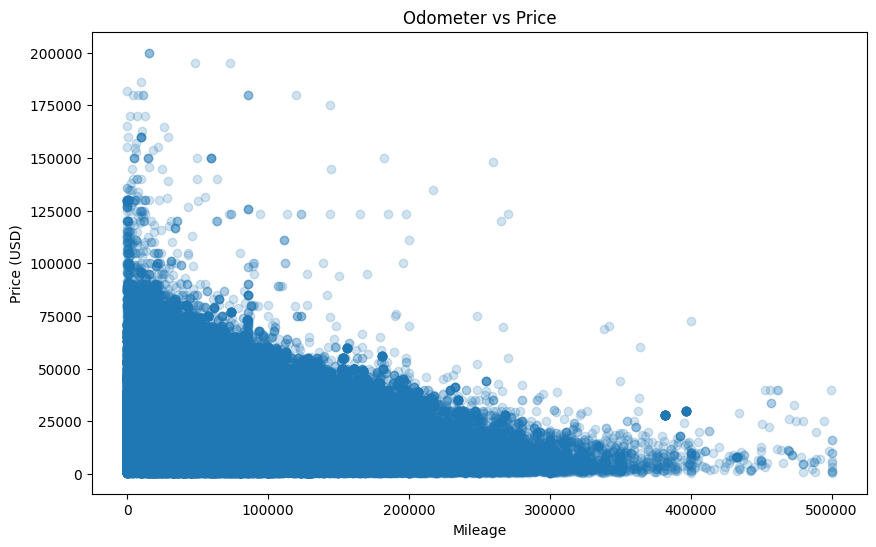

In [48]:
# Odometer vs Price

plt.figure(figsize=(10,6))

plt.scatter(
    df['odometer'],
    df['price'],
    alpha=0.2
)

plt.title("Odometer vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price (USD)")

plt.show()

# 1️⃣2️⃣ Correlation Analysis

Visualize the correlation between numerical features.

In [49]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


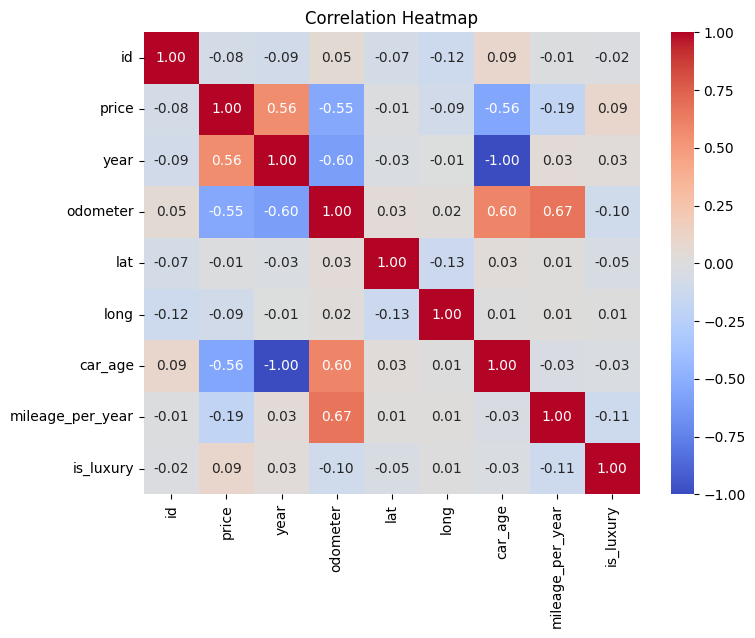

In [50]:
# Correlation Heatmap

import seaborn as sns

numeric_df = df.select_dtypes(include=['int64','int32','float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [51]:
df.to_csv("cleaned_used_cars.csv", index=False)

# 📌 Business Insights

### Key Findings

- The used car market is dominated by affordable and mid-range vehicles.
- Ford, Chevrolet, and Toyota have the highest number of listings.
- Luxury brands such as Ferrari, Aston Martin, Tesla, and Porsche have the highest average resale prices.
- Vehicle condition strongly affects resale value.
- Newer vehicles are generally more expensive.
- Higher mileage is associated with lower resale prices.
- Fuel type, transmission, and vehicle type significantly influence pricing.
- Geographic location also contributes to price variation.

These insights guided feature selection for the machine learning model.

# ✅ Phase 2 Summary: Exploratory Data Analysis (EDA)

The exploratory data analysis provided valuable insights into the used car market and helped identify the key factors affecting vehicle prices.

## 📌 Tasks Completed

- ✔ Dataset Overview
- ✔ Price Distribution Analysis
- ✔ Manufacturer Analysis
- ✔ Top Models Analysis
- ✔ Fuel Type Analysis
- ✔ Transmission Analysis
- ✔ Vehicle Type Analysis
- ✔ Vehicle Condition Analysis
- ✔ State-wise Analysis
- ✔ Manufacturing Year vs Price
- ✔ Odometer vs Price
- ✔ Correlation Analysis
- ✔ Business Insights

## 🔍 Key Findings

- The used car market is dominated by affordable and mid-range vehicles.
- Ford, Chevrolet, and Toyota have the highest number of listings.
- Luxury brands such as Ferrari, Aston Martin, Tesla, and Porsche have the highest average resale prices.
- Vehicle condition significantly impacts resale value.
- Newer vehicles generally have higher prices than older vehicles.
- Higher mileage is associated with lower resale prices.
- Fuel type, transmission, and vehicle type influence pricing patterns.
- Geographic location also contributes to price variation.

## 🎯 Conclusion

The EDA phase improved our understanding of the dataset and identified the most influential features for predicting used car prices. These insights will guide feature selection, model training, and performance optimization in the next phase of the project.

➡ **Next Phase:** Machine Learning Model Development

# 🤖 Phase 3: Machine Learning Model Development

### Objective

Build multiple machine learning models to predict the selling price of used cars and compare their performance using different evaluation metrics.

# 1️⃣ Feature Selection

Select input features (X) and target variable (y).

In [52]:
# Feature Selection

features = [

    'manufacturer',

    'model',

    'year',

    'condition',

    'cylinders',

    'fuel',

    'odometer',

    'title_status',

    'transmission',

    'drive',

    'type',

    'paint_color',

    'state',

    'car_age',

    'mileage_per_year',

    'is_luxury'

]

X = df[features]

y = df['price']

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (357751, 16)
Target Shape : (357751,)


In [ ]:
df.to_csv("cleaned_used_cars.csv", index=False)

# 2️⃣ Train Test Split

Split the dataset into training and testing sets.

In [53]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (286200, 16)
Testing Samples : (71551, 16)


# 3️⃣ Data Preprocessing

Separate numerical and categorical features.

In [54]:
# Numerical & Categorical Features

categorical_features = [

    'manufacturer',

    'model',

    'condition',

    'cylinders',

    'fuel',

    'title_status',

    'transmission',

    'drive',

    'type',

    'paint_color',

    'state'

]

numerical_features = [

    'year',

    'odometer',

    'car_age',

    'mileage_per_year',

    'is_luxury'

]

print("Categorical Features :", len(categorical_features))

print("Numerical Features :", len(numerical_features))

Categorical Features : 11
Numerical Features : 5


# 4️⃣ Data Preprocessing Pipeline

Apply One-Hot Encoding to categorical features while keeping numerical features unchanged.

In [55]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(

    transformers=[

        (

            'cat',

            OneHotEncoder(handle_unknown='ignore'),

            categorical_features

        ),

        (

            'num',

            'passthrough',

            numerical_features

        )

    ]

)

print("Preprocessing Pipeline Ready")

Preprocessing Pipeline Ready


# 5️⃣ Baseline Model: Linear Regression

Train a baseline regression model for comparison with advanced algorithms.

In [56]:
# Linear Regression Pipeline

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(

    steps=[

        ('preprocessor', preprocessor),

        ('model', LinearRegression())

    ]

)

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [57]:
# Model Prediction

y_pred_lr = linear_model.predict(X_test)

print("Prediction Completed")

Prediction Completed


# 6️⃣ Model Evaluation

Evaluate the Linear Regression model using MAE, RMSE, and R² Score.

In [58]:
# Model Evaluation

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

MAE : 5920.84
RMSE : 8774.52
R² Score : 0.6336


# 7️⃣ Decision Tree Regressor

Train a Decision Tree model and compare its performance with the baseline Linear Regression model.

In [59]:
# Decision Tree Pipeline

from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42,
            max_depth=20,
            min_samples_split=10
        ))
    ]
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully ")

Decision Tree Model Trained Successfully 


In [60]:
# Decision Tree Prediction

y_pred_dt = decision_tree.predict(X_test)

print("Prediction Completed ")

Prediction Completed 


In [61]:
# Decision Tree Evaluation

mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", round(mae_dt,2))

print("RMSE :", round(rmse_dt,2))

print("R² Score :", round(r2_dt,4))

MAE : 3315.64
RMSE : 6019.82
R² Score : 0.8275


In [62]:
df.to_csv("cleaned_used_cars.csv", index=False)

# 8️⃣ Random Forest Regressor

Train an ensemble learning model to improve prediction accuracy and reduce overfitting.

In [ ]:
# ==========================================
# Random Forest Pipeline
# ==========================================

from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully ")

In [ ]:
# ==========================================
# Create Sample Dataset for Faster Training
# ==========================================

df_sample = df.sample(
    n=100000,
    random_state=42
)

print(df_sample.shape)

In [ ]:
# Random Forest Pipeline

from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=50,      # 100 -> 50
            max_depth=20,         # Limit tree depth
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

In [ ]:
# Random Forest Prediction

y_pred_rf = random_forest.predict(X_test)

print("Prediction Completed")

In [ ]:
# Random Forest Evaluation

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", round(mae_rf,2))

print("RMSE :", round(rmse_rf,2))

print("R² Score :", round(r2_rf,4))

In [ ]:
# Compare Models

comparison = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE':[
        mae,
        mae_dt,
        mae_rf
    ],

    'RMSE':[
        rmse,
        rmse_dt,
        rmse_rf
    ],

    'R² Score':[
        r2,
        r2_dt,
        r2_rf
    ]

})

comparison.sort_values(
    by='R² Score',
    ascending=False
)